In [1]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import scanpy as sc
import anndata
import pandas as pd
from collections import defaultdict
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

GPU is available
Number of GPUs: 1
GPU Name: NVIDIA TITAN X (Pascal)


In [4]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 6
n_var = 250
n_components = 10
n_datapoints = 50000
locs_range = 2
batch_size = 32

In [316]:
import math
import torch
from torch.distributions import constraints
from torch.distributions.utils import broadcast_all
from torch.distributions.transformed_distribution import TransformedDistribution
from torch.distributions.transforms import ExpTransform
from pyro.distributions import SoftLaplace, TorchDistribution

def log_diff_exp(a, b, eps=torch.tensor(1e-10)):
    """
    Numerically stable computation of log(exp(a) - exp(b)) given a >= b.
    Returns an approximation for very small differences to avoid -inf.
    """
    # Ensure that a >= b
    if torch.any(b > a):
        raise ValueError("For log_diff_exp, a must be greater than or equal to b.")
    
    # Use a threshold for small differences
    diff = a - b
    small_diff_mask = diff.abs() < eps
    
    # Safe computation for small differences
    result = torch.where(
        small_diff_mask,
        a + torch.log(eps),  # Approximation when a ≈ b
        a + torch.log1p(-torch.exp(b - a))
    )
    
    return result

class LogSoftLaplace(TransformedDistribution):
    r"""
    Creates a log-soft-laplace distribution parameterized by
    :attr:`loc` and :attr:`scale` where::

        X ~ SoftLaplace(loc, scale)
        Y = exp(X) ~ LogSoftLaplace(loc, scale)

    Args:
        loc (float or Tensor): mean of log of distribution
        scale (float or Tensor): standard deviation of log of the distribution
    """
    arg_constraints = {"loc": constraints.real, "scale": constraints.positive}
    support = constraints.nonnegative
    has_rsample = True

    def __init__(self, loc, scale, validate_args=None):
        self.loc = loc  # Explicitly set loc
        self.scale = scale  # Explicitly set scale
        base_dist = SoftLaplace(loc, scale, validate_args=validate_args)
        transforms = [ExpTransform()]
        super().__init__(base_dist, transforms, validate_args=validate_args)

    def expand(self, batch_shape, _instance=None):
        new = self._get_checked_instance(LogSoftLaplace, _instance)
        batch_shape = torch.Size(batch_shape)
        new.loc = self.loc.expand(batch_shape)
        new.scale = self.scale.expand(batch_shape)
        new.base_dist = self.base_dist.expand(batch_shape)
        super(LogSoftLaplace, new).__init__(
            new.base_dist, self.transforms, validate_args=self._validate_args
        )
        return new

    @property
    def mean(self):
        # Implement the mean if possible; placeholder here
        return (self.loc + (math.pi / 2 * self.scale) ** 2 / 2).exp()

    @property
    def variance(self):
        scale_sq = (math.pi / 2 * self.scale) ** 2
        return (scale_sq.expm1() * (2 * self.loc + scale_sq).exp())

    def entropy(self):
        return self.base_dist.entropy() + self.loc

    def log_cdf(self, value):
        """
        Computes the log CDF of the LogSoftLaplace distribution at the given value.
        """
        if self._validate_args:
            self._validate_sample(value)
        # Ensure value is positive
        value = torch.clamp(value, min=torch.finfo(value.dtype).tiny)
        # Transform value back to the base distribution's scale
        log_value = torch.log(value)
        z = (log_value - self.loc) / self.scale
        # Compute the CDF of the SoftLaplace distribution
        cdf = torch.atan(torch.exp(z)) * (2 / math.pi)
        # Compute log CDF, ensuring numerical stability
        return torch.log(cdf + torch.finfo(value.dtype).eps)

class FlooredLogSoftLaplace(TorchDistribution):
    """
    Floored Log-Soft-Laplace distribution.

    This distribution corresponds to flooring the samples from a Log-Soft-Laplace distribution,
    making the distribution discrete. The pmf is computed using the log CDF values for numerical stability.

    Args:
        loc (float or Tensor): Location parameter.
        scale (float or Tensor): Scale parameter.
    """
    arg_constraints = {"loc": constraints.real, "scale": constraints.positive}
    support = constraints.nonnegative_integer
    has_rsample = True

    def __init__(self, loc, scale, validate_args=None):
        self.loc, self.scale = broadcast_all(loc, scale)
        self.base_dist = LogSoftLaplace(self.loc, self.scale, validate_args=validate_args)
        batch_shape = self.loc.size()
        super().__init__(batch_shape, validate_args=validate_args)

    def expand(self, batch_shape, _instance=None):
        new = self._get_checked_instance(FlooredLogSoftLaplace, _instance)
        batch_shape = torch.Size(batch_shape)
        new.loc = self.loc.expand(batch_shape)
        new.scale = self.scale.expand(batch_shape)
        new.base_dist = self.base_dist.expand(batch_shape)
        super(FlooredLogSoftLaplace, new).__init__(
            batch_shape, validate_args=self._validate_args
        )
        return new

    def log_prob(self, value):
        if self._validate_args:
            self._validate_sample(value)
        value = value.long()
    
        # Broadcast all tensors to ensure compatible shapes
        self.loc, self.scale, value = torch.broadcast_tensors(self.loc, self.scale, value)
        
        # Compute log_cdf at value and value + 1
        log_cdf_value = self.base_dist.log_cdf(value.float())
        log_cdf_value_plus_1 = self.base_dist.log_cdf((value + 1).float())
        
        # Compute the log PMF using numerically stable log difference
        log_prob = log_diff_exp(log_cdf_value_plus_1, log_cdf_value)
    
        # Debugging: Print shapes to ensure alignment
        print("Shapes for debugging:")
        print("  value shape:", value.shape)
        print("  log_cdf_value shape:", log_cdf_value.shape)
        print("  log_cdf_value_plus_1 shape:", log_cdf_value_plus_1.shape)
        print("  loc shape:", self.loc.shape)
        print("  scale shape:", self.scale.shape)
        print("  log_prob shape:", log_prob.shape)
    
        # Identify where log_prob is -inf
        inf_mask = log_prob == float('-inf')
        if inf_mask.any():
            indices = torch.nonzero(inf_mask)
            for idx in indices:
                idx_tuple = tuple(idx.tolist())
                print(f"log_prob is -inf at index {idx_tuple}")
                print(f"  value: {value[idx_tuple]}")
                print(f"  log_cdf_value: {log_cdf_value[idx_tuple]}")
                print(f"  log_cdf_value_plus_1: {log_cdf_value_plus_1[idx_tuple]}")
                print(f"  loc: {self.loc[idx_tuple]}")
                print(f"  scale: {self.scale[idx_tuple]}")
    
        return log_prob

        
    def rsample(self, sample_shape=torch.Size()):
        samples = self.base_dist.rsample(sample_shape)
        return torch.floor(samples)

    @property
    def mean(self):
        # Approximate the mean for the discrete distribution
        return torcqrh.floor(self.base_dist.mean)

    @property
    def variance(self):
        # Approximate the variance
        mean_floor = torch.floor(self.base_dist.mean)
        mean_floor_plus_1 = mean_floor + 1
        p_floor = (
            self.base_dist.cdf(mean_floor_plus_1) - self.base_dist.cdf(mean_floor)
        )
        return mean_floor * (1 - p_floor) + mean_floor_plus_1 * p_floor - self.mean ** 2

    def entropy(self):
        # Entropy computation for discrete distributions can be complex
        raise NotImplementedError("Entropy is not implemented for FlooredLogSoftLaplace")


<Axes: ylabel='Count'>

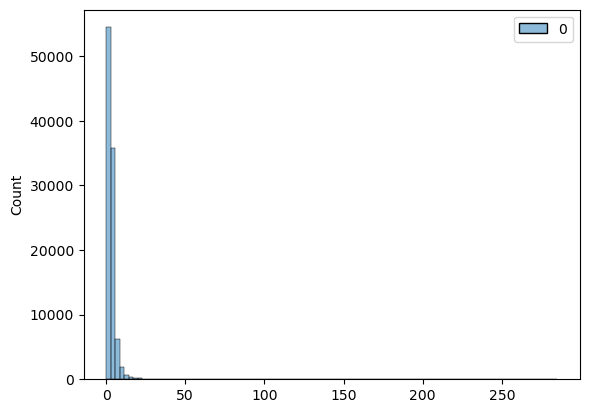

In [317]:
seaborn.histplot(LogSoftLaplace(loc=torch.zeros(1)+1,scale=0.3*torch.ones(1),validate_args=False).samplqe([100000]),bins=100)

<Axes: ylabel='Count'>

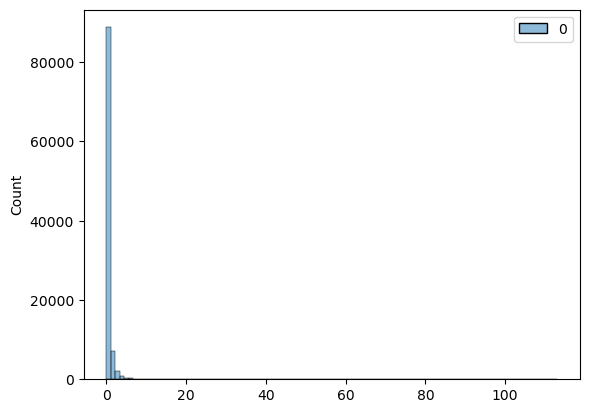

In [318]:
seaborn.histplot(FlooredLogSoftLaplace(loc=torch.zeros(1),scale=0.4*torch.ones(1),validate_args=False).sample([100000]),bins=100)

<Axes: ylabel='Count'>

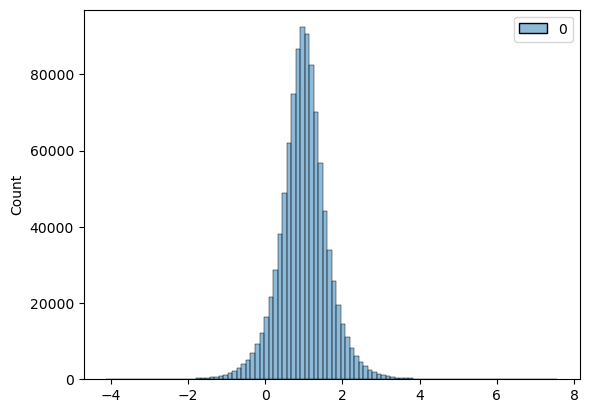

In [319]:
seaborn.histplot(dist.SoftLaplace(loc=torch.zeros(1)+1,scale=0.4*torch.ones(1),validate_args=False).sample([1000000]),bins=100)

<Axes: ylabel='Count'>

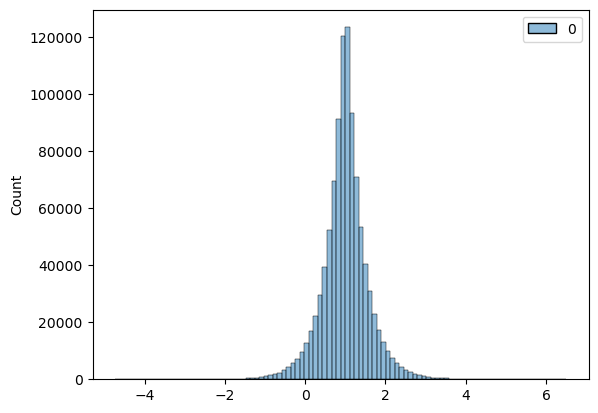

In [320]:
seaborn.histplot(dist.Laplace(loc=torch.zeros(1)+1,scale=0.4*torch.ones(1),validate_args=False).sample([1000000]),bins=100)

In [321]:
FlooredLogSoftLaplace(loc=torch.zeros(1)+1,scale=0.3*torch.ones(1),validate_args=False).log_prob(torch.tensor(7))

Shapes for debugging:
  value shape: torch.Size([1])
  log_cdf_value shape: torch.Size([1])
  log_cdf_value_plus_1 shape: torch.Size([1])
  loc shape: torch.Size([1])
  scale shape: torch.Size([1])
  log_prob shape: torch.Size([1])


tensor([-4.6296])

In [322]:
dist.SoftLaplace(loc=torch.zeros(1)+1,scale=0.3*torch.ones(1),validate_args=False).log_prob(7)

tensor([-19.2476])

In [323]:
dist.Laplace(loc=torch.zeros(1)+1,scale=0.3*torch.ones(1),validate_args=False).log_prob(7)

tensor([-19.4892])

In [324]:
grads=defaultdict(list)

import pyro
import pyro.ops.jit
from pyro.distributions.util import is_identically_zero
from pyro.infer.elbo import ELBO
from pyro.infer.enum import get_importance_trace
from pyro.infer.util import (
    MultiFrameTensor,
    get_plate_stacks,
    is_validation_enabled,
    torch_item,
)
from pyro.util import check_if_enumerated, warn_if_nan

class SafeSVI(pyro.infer.abstract_infer.TracePosterior):
    '''A version of pyro.infer.SVI that skips steps with loss more than X sigma from the running mean loss'''
    def __init__(
        self,
        model,
        guide,
        optim,
        loss,
        loss_and_grads=None,
        clip_std_multiplier=6.0,
        window_size=1000,  # Default window size of 300
        **kwargs
    ):
        super().__init__(**kwargs)
        self.model = model
        self.guide = guide
        self.optim = optim
        self.record = False
        self.clip_std_multiplier = clip_std_multiplier
        self.window_size = window_size
        self.losses = []  # Store recent losses to calculate running stats

        if not isinstance(optim, pyro.optim.PyroOptim):
            raise ValueError("Optimizer should be an instance of pyro.optim.PyroOptim class.")

        if isinstance(loss, ELBO):
            self.loss = loss.loss
            self.loss_and_grads = loss.loss_and_grads
        else:
            if loss_and_grads is None:
                def _loss_and_grads(*args, **kwargs):
                    loss_val = loss(*args, **kwargs)
                    if getattr(loss_val, "requires_grad", False):
                        loss_val.backward(retain_graph=True)
                    return loss_val
                self.loss_and_grads = _loss_and_grads
            else:
                self.loss_and_grads = loss_and_grads

    def _traces(self, *args, **kwargs):
        for i in range(self.num_samples):
            guide_trace = poutine.trace(self.guide).get_trace(*args, **kwargs)
            model_trace = poutine.trace(
                poutine.replay(self.model, trace=guide_trace)
            ).get_trace(*args, **kwargs)
            yield model_trace, 1.0

    def evaluate_loss(self, *args, **kwargs):
        with torch.no_grad():
            loss = self.loss(self.model, self.guide, *args, **kwargs)
            return torch_item(loss)

    def step(self, *args, **kwargs):
        # Compute loss and gradients
        with poutine.trace(param_only=True) as param_capture:
            loss = self.loss_and_grads(self.model, self.guide, *args, **kwargs)
    
        loss_val = torch_item(loss)
        self.losses.append(loss_val)
        # Keep only the last `window_size` losses
        if len(self.losses) > self.window_size:
            self.losses.pop(0)
        # Extract params early to ensure they are defined for later use
        params = set(site["value"].unconstrained() for site in param_capture.trace.nodes.values())
        
        # Calculate running mean and std only if we have enough data
        if len(self.losses) >= self.window_size:
            running_mean = np.mean(self.losses)
            running_std = np.std(self.losses)
            #print(loss, running_mean,running_std)
            if ((loss > running_mean-running_std*self.clip_std_multiplier) and (loss < running_mean+running_std*self.clip_std_multiplier)):
                # Perform optimization step
                self.optim(params)
            else:
                print('STEP SKIPPED')
        else:
            self.optim(params)
        
        if self.record:
            for name, value in pyro.get_param_store().named_parameters():
                grads[name].append(value.grad.detach().cpu().numpy())
        
        # Zero gradients
        pyro.infer.util.zero_grads(params)
    
        return loss_val

In [325]:
def minmax(x):
    return(x.min(),x.max())

In [326]:
class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.scale=1e-4
        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(num_var=self.n_var, hidden_dims=[1000, 1000, 1000], outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)])
        self.classifier = antipode.train_utils.SimpleFFNN(in_dim=self.n_latent, hidden_dims=[1000, 1000, 1000], out_dim=self.n_components)

    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                l = data.sum(-1).unsqueeze(-1) + 1.
                
                # Ensure parameters are leaf tensors
                locs = pyro.param('locs', 0.1 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                transform_matrix = pyro.param('transform_matrix', 0.1 * torch.rand(self.n_latent, self.n_var, device=device))

                intercept = pyro.param('intercept', torch.zeros(self.n_components, self.n_var, device=device))
                total_counts = pyro.param('total_counts', 2 * torch.ones(self.n_var, device=device), constraint=constraints.positive)
                
                z = pyro.sample('z', dist.Categorical(logits=torch.ones(self.n_components, device=device),validate_args=True), infer={"enumerate": "parallel"})
                latent = pyro.sample('latent', dist.Normal(locs[z], scales[z]).to_event(1))
                out_mu = latent @ transform_matrix + intercept[z]
                norm_mu=torch.nn.functional.log_softmax(out_mu,dim=-1) + l.log()
                print('logprob',minmax(FlooredLogSoftLaplace(loc=norm_mu,scale=total_counts,validate_args=False).log_prob(data)))
                print(minmax(norm_mu))
                pyro.sample('obs', FlooredLogSoftLaplace(loc=norm_mu,scale=total_counts,validate_args=True).to_event(1), obs=data)
                # recon = pyro.sample('obs', dist.NegativeBinomial(total_count=total_counts, logits=logits,validate_args=False).to_event(1), obs=data)
                # return recon


    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                locs_mu, locs_std = self.encoder(data)
                latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std,validate_args=True).to_event(1))
                weights_probs = pyro.sample('z', dist.Categorical(logits=self.classifier(latent),validate_args=True), infer={"enumerate": "parallel"})

In [327]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000,locs_range=2.):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range
    scales = torch.ones(n_components, n_latent) * 0.5
    transform_matrix = 1.*torch.randn(n_latent, n_var)
    intercept = 4*torch.rand(n_components, n_var)-2.
    overall_intercept = 16*torch.rand(n_var)-8.
    data = []
    true_clusters=[]
    true_latent=[]
    for _ in range(n_datapoints):
        l = 7 + 2*torch.rand(1)
        z = torch.multinomial(weights, 1).item()
        true_clusters.append(z)
        latent = torch.normal(locs[z], scales[z])
        true_latent.append(latent)
        out_mu = latent @ transform_matrix + intercept[z] + overall_intercept
        total_counts = torch.tensor(25.0)
        logits = (torch.softmax(out_mu,dim=-1)*l.exp()).log() - torch.log(total_counts) 
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data),{'latent':true_latent,'clusters':true_clusters,'weights':weights,'locs':locs,'scales':scales,'intercept':intercept}

# Generate synthetic data
# data, true_params = generate_synthetic_data(n_datapoints=n_datapoints)
# adata=anndata.AnnData(X=data.cpu().numpy(),obs=pd.DataFrame([str(x) for x in true_params['clusters']],columns=['true_clusters']))
# adata.obsm['true_latents']=np.stack(true_params['latent'],axis=0)

In [328]:
# seaborn.histplot(np.log(data.flatten()+0.1))

In [329]:
# seaborn.histplot(data.sum(1).flatten(),bins=10)

In [330]:
toy_model = ToyModel(n_latent = n_latent+5,n_var = n_var,n_components = n_components+5)
toy_model.to(device)
grads=defaultdict(list)

# SVI setup
adam_params = {"lr": 0.005}
optimizer = Adam(adam_params)
svi = SafeSVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.TraceEnum_ELBO())

# Training loop
num_iterations = 30
losses = []

In [331]:
for i in tqdm.tqdm(range(num_iterations)):
    svi.record=False
    if i==num_iterations-1:
        svi.record=True
    loss = 0
    for j in range(0, n_datapoints, batch_size):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
    print(f"Iteration {i} : Loss {loss}")

print("Training complete.")

  0%|          | 0/30 [00:00<?, ?it/s]

Shapes for debugging:
  value shape: torch.Size([32, 250])
  log_cdf_value shape: torch.Size([32, 250])
  log_cdf_value_plus_1 shape: torch.Size([32, 250])
  loc shape: torch.Size([32, 250])
  scale shape: torch.Size([32, 250])
  log_prob shape: torch.Size([32, 250])
logprob (tensor(-12.9907, device='cuda:0', grad_fn=<MinBackward1>), tensor(-1.0611, device='cuda:0', grad_fn=<MaxBackward1>))
(tensor(0.8939, device='cuda:0', grad_fn=<MinBackward1>), tensor(3.9875, device='cuda:0', grad_fn=<MaxBackward1>))
Shapes for debugging:
  value shape: torch.Size([32, 250])
  log_cdf_value shape: torch.Size([32, 250])
  log_cdf_value_plus_1 shape: torch.Size([32, 250])
  loc shape: torch.Size([32, 250])
  scale shape: torch.Size([32, 250])
  log_prob shape: torch.Size([32, 250])
Shapes for debugging:
  value shape: torch.Size([15, 32, 250])
  log_cdf_value shape: torch.Size([15, 32, 250])
  log_cdf_value_plus_1 shape: torch.Size([15, 32, 250])
  loc shape: torch.Size([15, 32, 250])
  scale shape: t

  0%|          | 0/30 [00:02<?, ?it/s]

Shapes for debugging:
  value shape: torch.Size([15, 32, 250])
  log_cdf_value shape: torch.Size([15, 32, 250])
  log_cdf_value_plus_1 shape: torch.Size([15, 32, 250])
  loc shape: torch.Size([15, 32, 250])
  scale shape: torch.Size([15, 32, 250])
  log_prob shape: torch.Size([15, 32, 250])
logprob (tensor(-14.2411, device='cuda:0', grad_fn=<MinBackward1>), tensor(-0.0016, device='cuda:0', grad_fn=<MaxBackward1>))
(tensor(-14.4766, device='cuda:0', grad_fn=<MinBackward1>), tensor(5.4946, device='cuda:0', grad_fn=<MaxBackward1>))
Shapes for debugging:
  value shape: torch.Size([15, 32, 250])
  log_cdf_value shape: torch.Size([15, 32, 250])
  log_cdf_value_plus_1 shape: torch.Size([15, 32, 250])
  loc shape: torch.Size([15, 32, 250])
  scale shape: torch.Size([15, 32, 250])
  log_prob shape: torch.Size([15, 32, 250])
Shapes for debugging:
  value shape: torch.Size([15, 32, 250])
  log_cdf_value shape: torch.Size([15, 32, 250])
  log_cdf_value_plus_1 shape: torch.Size([15, 32, 250])
  loc

ValueError: Expected parameter loc (Tensor of shape (32, 11)) of distribution Normal(loc: torch.Size([32, 11]), scale: torch.Size([32, 11])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, 

In [ ]:
grads['transform_matrix']

In [ ]:
antipode.plotting.plot_loss(losses)

In [147]:
pyro.param('total_counts')

tensor([0.2596, 1.5094, 2.1504, 0.2258, 0.6368, 0.6201, 0.5698, 0.2433, 1.3367,
        3.2255, 0.9619, 0.2312, 0.2622, 0.3150, 0.2241, 4.0679, 0.7540, 0.2347,
        0.6475, 0.2238, 0.2342, 0.2283, 0.7007, 0.8229, 0.2802, 0.2305, 2.8943,
        0.2239, 0.4855, 0.2238, 0.2241, 1.1877, 1.2026, 0.7511, 0.2243, 0.2250,
        0.4801, 0.2524, 0.2247, 0.2264, 0.2267, 0.2327, 0.6584, 0.4015, 0.2251,
        0.9577, 0.2330, 0.3592, 0.2240, 0.3161, 0.9600, 0.8299, 0.7309, 0.2238,
        0.2240, 0.2241, 0.2992, 0.3033, 0.8199, 1.0921, 0.2240, 0.2299, 0.2243,
        0.2352, 0.2239, 0.2239, 0.2239, 0.9167, 0.2245, 2.7029, 1.6285, 3.2388,
        1.1866, 0.9478, 2.0307, 0.2581, 0.5942, 0.3558, 0.5796, 0.6548, 0.2787,
        0.2238, 0.2258, 0.3254, 0.2243, 0.2258, 0.2983, 0.2353, 0.2254, 1.1105,
        0.2594, 0.3778, 0.2896, 0.2240, 0.8764, 0.2957, 0.9995, 0.9433, 3.7215,
        1.1280, 0.2948, 0.2244, 0.2279, 0.2249, 4.2098, 0.2429, 0.2311, 0.8078,
        0.2238, 0.2353, 0.2238, 0.6615, 

In [148]:
toy_model.eval()
latents=[]
clusters=[]
for j in range(0, n_datapoints, batch_size):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [149]:
adata.obsm['rec_latents']=np.concatenate(latents,axis=0)
adata.obs['rec_clusters']=np.concatenate(clusters,axis=0).argmax(-1)
adata.obs['rec_clusters']=adata.obs['rec_clusters'].astype(str)

In [150]:
out_locs = pyro.param('locs').detach().cpu().numpy()
out_transform_matrix = pyro.param('transform_matrix').detach().cpu().numpy()
out_intercept = pyro.param('intercept').detach().cpu().numpy()
out_total_counts = pyro.param('total_counts').detach().cpu().numpy()

# Compute the learned cluster means
learned_means = out_locs @ out_transform_matrix + out_intercept #+ (out_total_counts**2/2)
learned_means_clusters=[str(x) for x in range(learned_means.shape[0])]
#actual_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
actual_means = antipode.model_functions.group_aggr_anndata(adata,['rec_clusters'],normalize=True)
learned_means=learned_means[pd.Series(learned_means_clusters).isin(actual_means[1]['rec_clusters']),:]
actual_means=np.log(actual_means[0]+actual_means[0][actual_means[0]>0].min()*0.9)

100%|██████████| 7/7 [00:00<00:00, 80.70it/s]


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


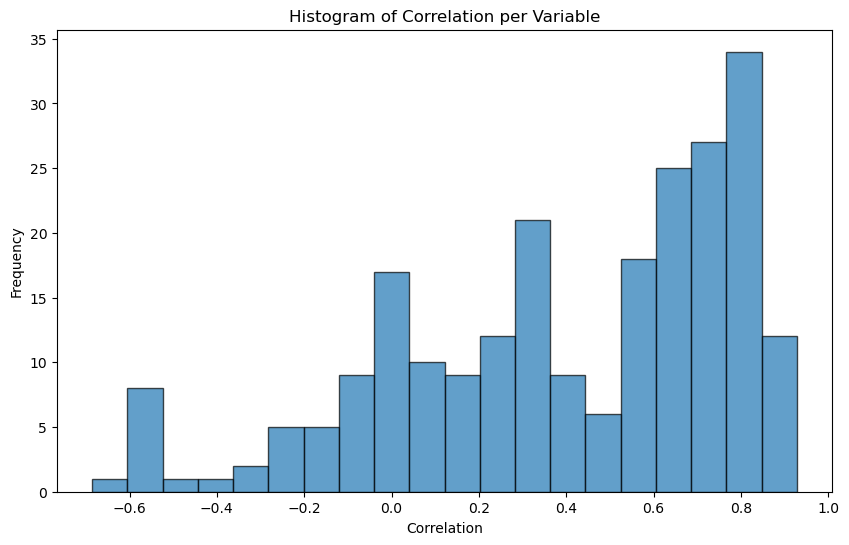

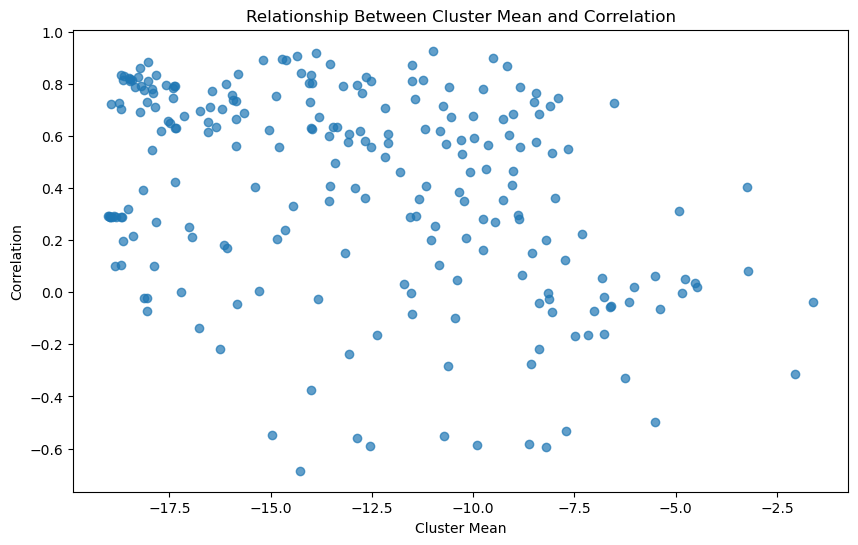

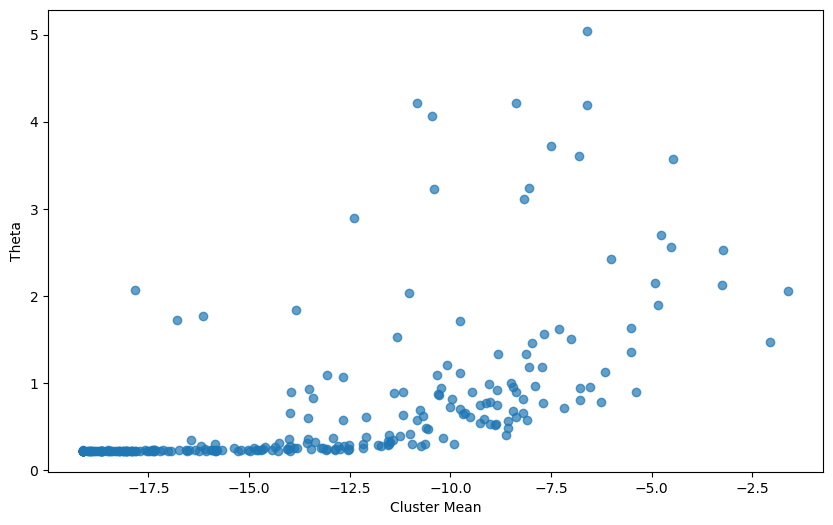

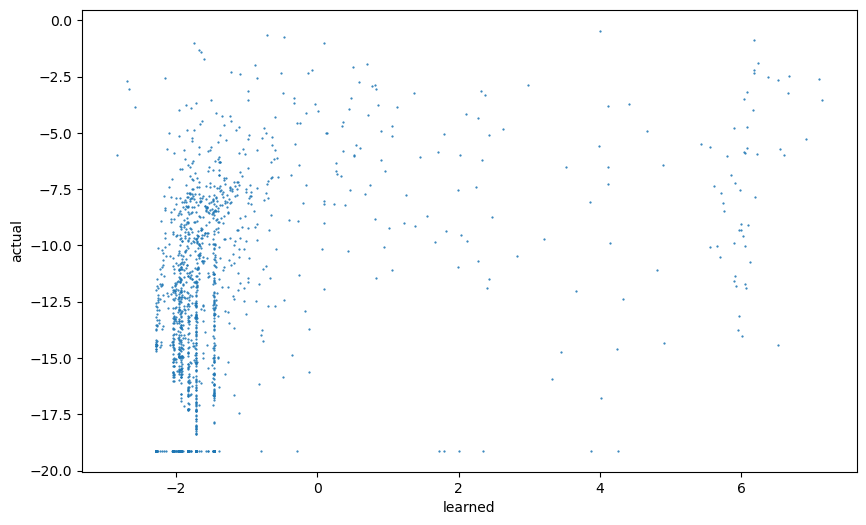

In [151]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), pyro.param('total_counts').cpu().detach().numpy(), alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Theta')
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(learned_means.flatten(),actual_means.flatten(),s=0.3)
plt.ylabel('actual')
plt.xlabel('learned')
plt.show()


In [120]:
adata.obsm['rec_mde']=scvi.model.utils.mde(adata.obsm['rec_latents'],init='random')
adata.obsm['true_mde']=scvi.model.utils.mde(adata.obsm['true_latents'],init='random')

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


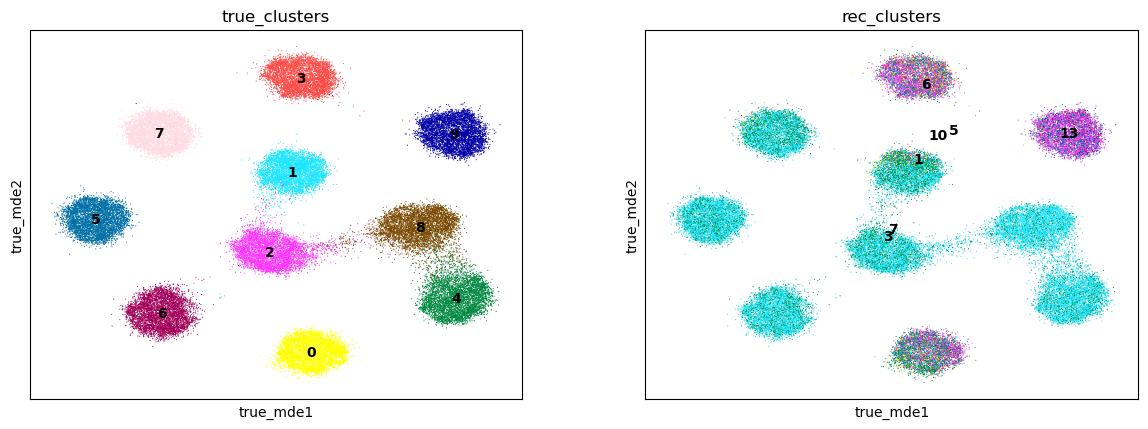

In [152]:
sc.pl.embedding(
    adata,
    basis='true_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


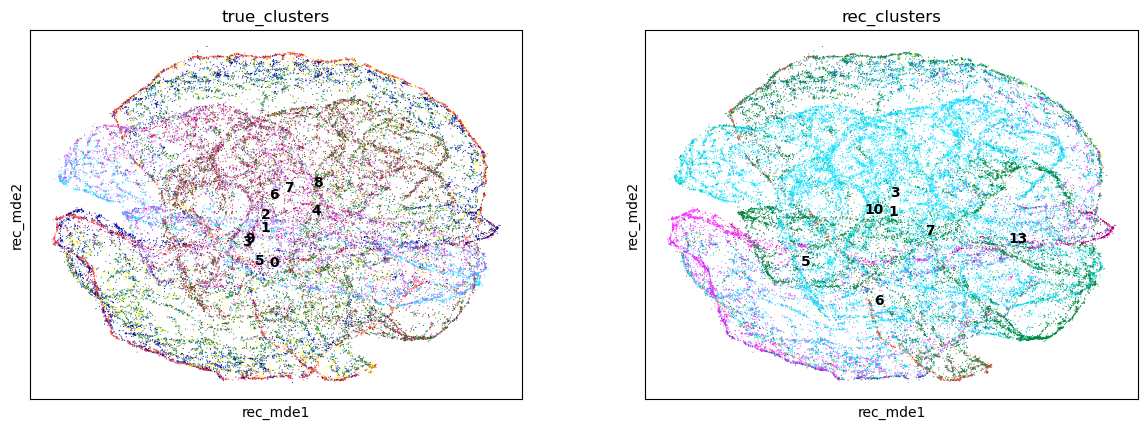

In [153]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

In [154]:
total_counts=5*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)


In [155]:
FlooredLogSoftLaplace(loc=torch.zeros(1)+3,scale=1*torch.ones(1),validate_args=False).sample([100000]).mean().log()

tensor(5.0976)

<Axes: ylabel='Count'>

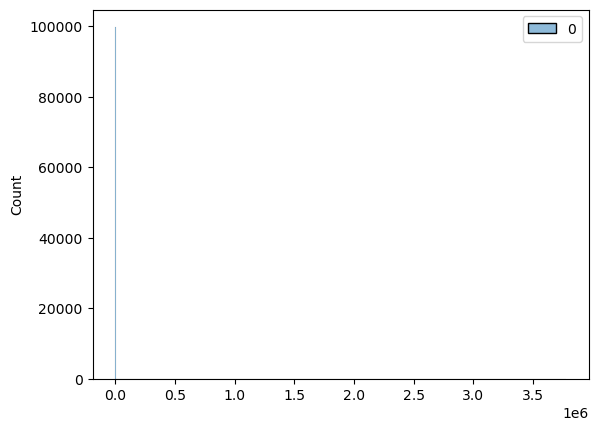

In [156]:
seaborn.histplot(FlooredLogSoftLaplace(loc=torch.zeros(1)+3,scale=1*torch.ones(1),validate_args=False).sample([100000]),bins=1000)

In [157]:
FlooredLogSoftLaplace(loc=mus,scale=total_counts,validate_args=False).base_dist

LogSoftLaplace(loc: torch.Size([1, 1000]), scale: torch.Size([1, 1000]))

In [158]:
log_probs=FlooredLogSoftLaplace(loc=mus,scale=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())

<Axes: >

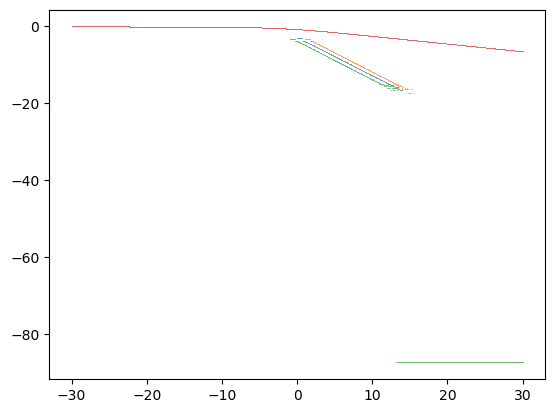

In [159]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.5)

<Axes: >

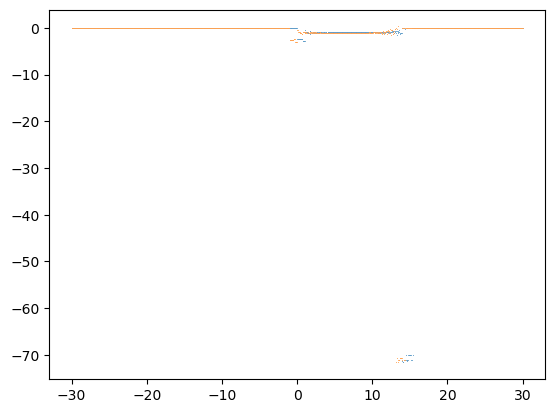

In [160]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


<Axes: >

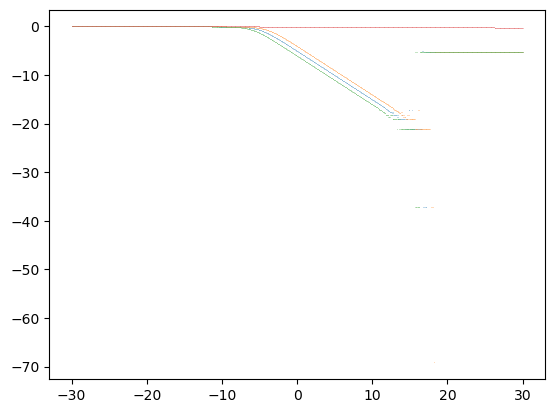

In [161]:
total_counts=(-5*torch.ones(1)).exp()
log_probs=dist.NegativeBinomial(total_count=total_counts,logits=mus-total_counts.log(),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.2)

In [162]:
total_counts.exp()

tensor([1.0068])

In [163]:
dist.NegativeBinomial(total_count=(torch.ones(1)+10).exp(),logits=torch.ones(1)+10,validate_args=False).sample([100000])

tensor([[3.5921e+09],
        [3.5614e+09],
        [3.5824e+09],
        ...,
        [3.5853e+09],
        [3.5798e+09],
        [3.5736e+09]])

tensor(8.)
tensor(0.1353)
tensor(10.)
tensor(1.)
tensor(12.)
tensor(7.3891)
tensor(14.)
tensor(54.5981)


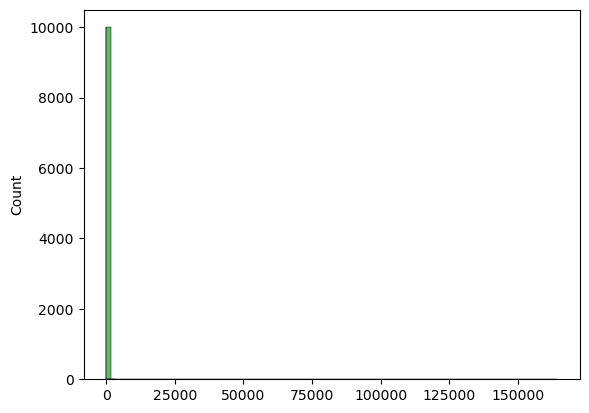

In [164]:
for i in [-2,0,2,4]: 
    total_counts=-torch.tensor(10.)
    print(torch.tensor(i)-total_counts)
    print(torch.tensor(i).exp())
    seaborn.histplot(dist.NegativeBinomial(total_count=(total_counts).exp(),logits=torch.tensor(i)-total_counts,validate_args=False).sample([10000]),bins=100)

<Axes: >

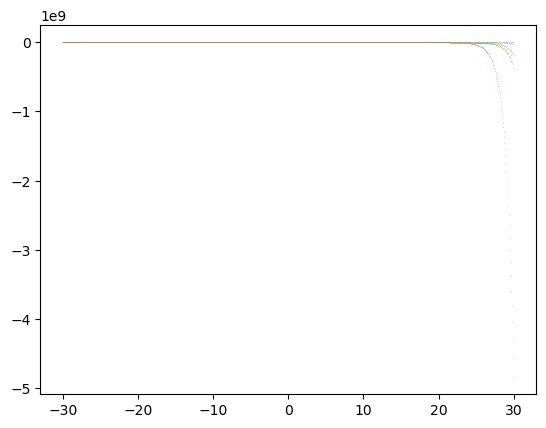

In [76]:
total_counts=mus-10.
log_probs=dist.NegativeBinomial(total_count=total_counts.exp(),logits=mus-total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.2)

<Axes: >

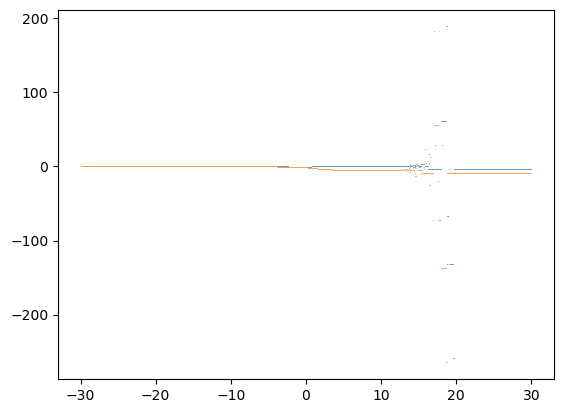

In [18]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


<Axes: >

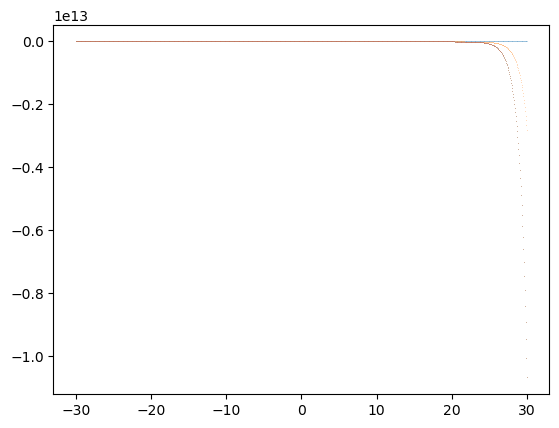

In [10]:
total_counts=mus-10.
log_probs=dist.Poisson(rate=mus.exp(),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.2)

In [19]:
total_counts=1*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)
log_probs=dist.NegativeBinomial(total_count=total_counts,probs=total_counts/(mus.exp()+total_counts),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1],dim=0).exp())

<Axes: >

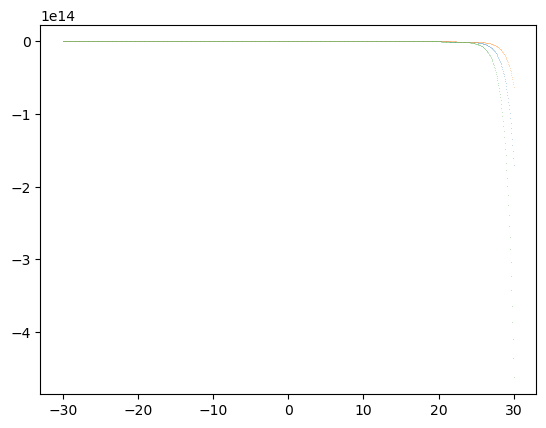

In [20]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.2)

<Axes: >

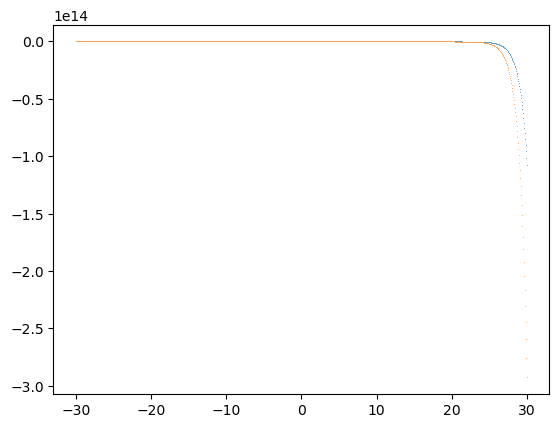

In [21]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [58]:
log_probs=dist.LogNormal(loc=mus,scale=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0).exp())

<Axes: >

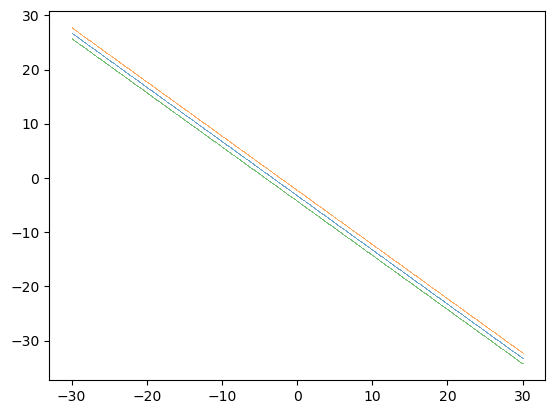

In [59]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

<Axes: >

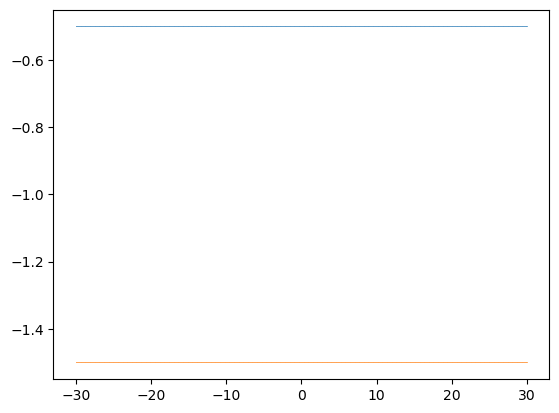

In [24]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [25]:
log_probs=dist.RelaxedBernoulli(temperature=0.0001*torch.ones(1),logits=mus,validate_args=False).log_prob(torch.sigmoid(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0)))

<Axes: >

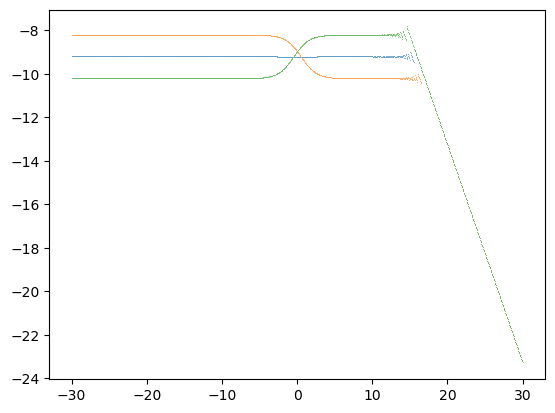

In [26]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

<Axes: >

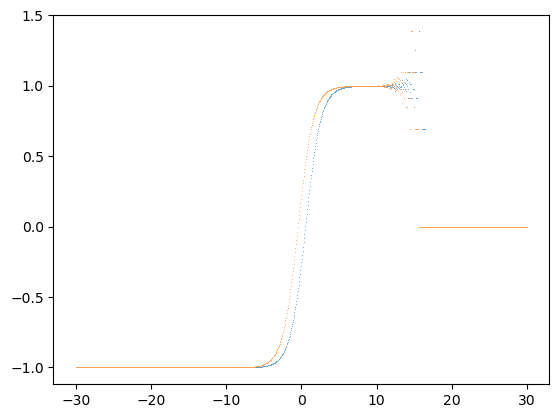

In [27]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)

In [43]:
(
    -torch.lgamma(total_counts + 0)
    + torch.lgamma(1.0 + torch.zeros(1))
    + torch.lgamma(total_counts)
)

tensor([0.])

In [ ]:
print(dist.NegativeBinomial(total_count=s_theta,logits=logits).log_prob(torch.zeros(1)).exp())
print(dist.Bernoulli(,probs=1-((s_theta * torch.nn.functional.logsigmoid(-logits))).exp()).log_prob(torch.zeros(1)).exp())

In [ ]:
print(dist.Bernoulli(,probs=1-((s_theta * torch.nn.functional.logsigmoid(-logits))).exp()).log_prob(torch.zeros(1)).exp())

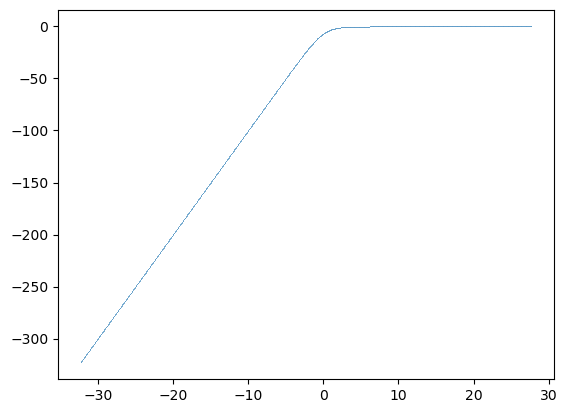

<Axes: >

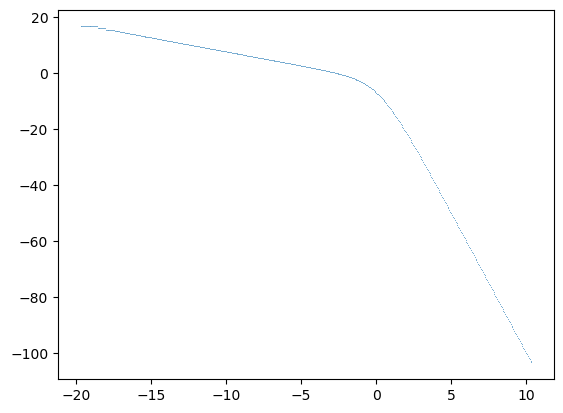

In [61]:
-seaborn.scatterplot(x=logits.numpy().flatten(),y=(total_counts * torch.nn.functional.logsigmoid(logits)).numpy().flatten(),s=0.5)
plt.show()
seaborn.scatterplot(x=logits.numpy().flatten(),y=torch.logit((total_counts * torch.nn.functional.logsigmoid(-logits)).exp()).numpy().flatten(),s=0.5)


<Axes: >

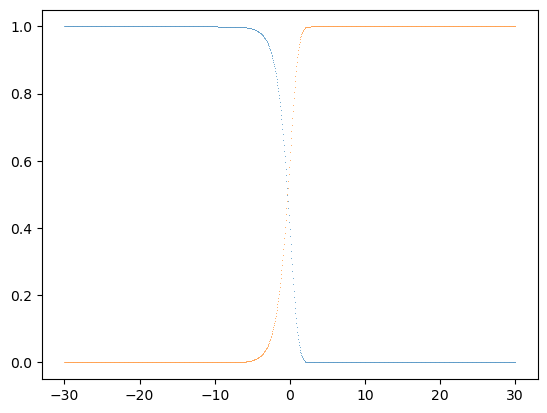

In [54]:
logits=mus-total_counts.log()
log_probs=dist.Bernoulli(probs=1-((total_counts * torch.nn.functional.logsigmoid(-logits))).exp()).log_prob(torch.cat([mus.new_zeros(mus.shape),mus.new_ones(mus.shape)],dim=0))
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].exp().numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].exp().numpy().flatten(),s=0.5)


In [4]:
log_probs=dist.Bernoulli(logits=mus,validate_args=False).log_prob(torch.sigmoid(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0)))

<Axes: >

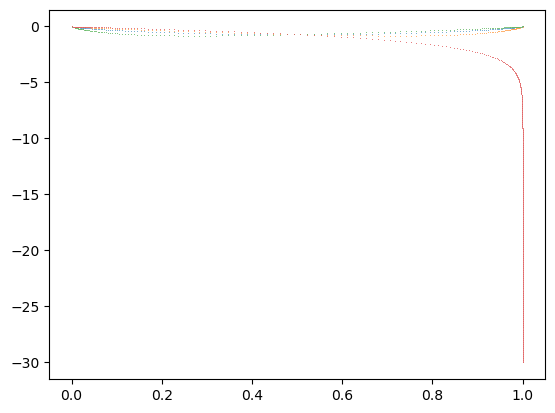

In [5]:
seaborn.scatterplot(x=torch.sigmoid(mus).numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=torch.sigmoid(mus).numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=torch.sigmoid(mus).numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=torch.sigmoid(mus).numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.5)

<Axes: >

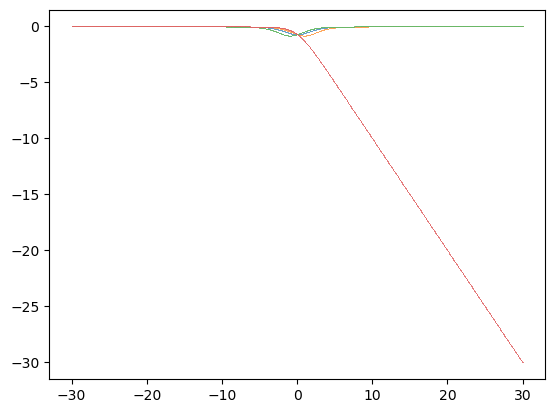

In [6]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.5)

<Axes: >

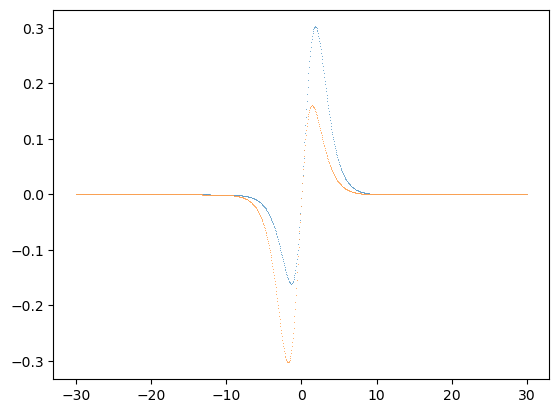

In [30]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)

<Axes: >

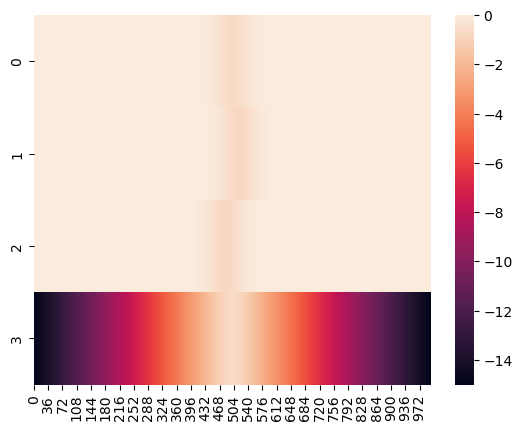

In [31]:
seaborn.heatmap(log_probs.numpy())

<Axes: >

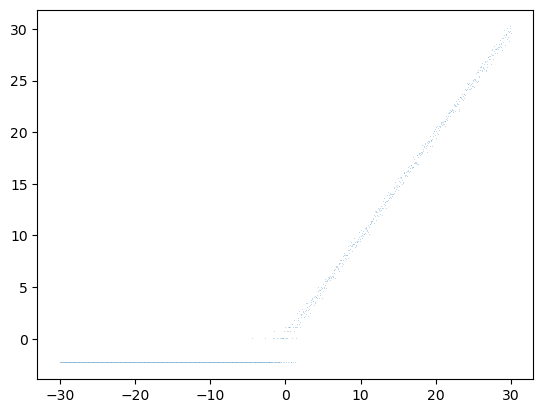

In [32]:
total_counts=10*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)
nb_outs=dist.NegativeBinomial(total_count=total_counts,logits=mus-total_counts.log(),validate_args=False).sample()
seaborn.scatterplot(x=mus.numpy().flatten(),y=np.log(nb_outs.numpy().flatten()+1e-1),s=0.2)

<Axes: >

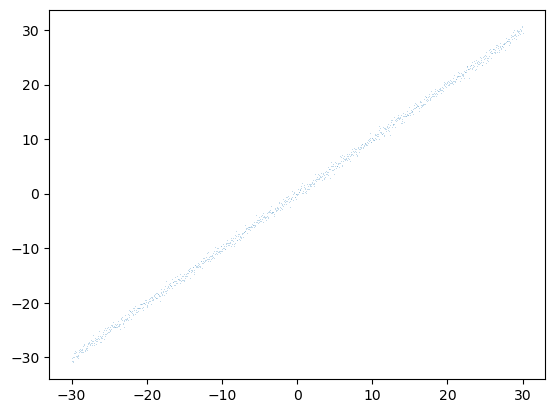

In [33]:
ln_outs=dist.LogNormal(loc=mus,scale=5/total_counts,validate_args=False).sample()
seaborn.scatterplot(x=mus.numpy().flatten(),y=np.log(ln_outs.numpy().flatten()+1e-15),s=0.2)